# Metriche riguardanti i post

In questo notebook, dopo l'esecuzione dello script _post_analysis.py_, che permette di salvare i dati ritenuti rilevanti in maniera da evitare il ricalcolo di ciascuno di essi ogni volta, viene descritto con delle "metriche" sintattiche la composizione del dataset, analizzando solamente i post, senza scendere a livello di frase

In [2]:
## Caricamento del dataframe
import pandas as pd

data = pd.read_csv('../data/analysis/post_analysis.csv')

data.head(5)

,post_id,submolt,text,post_length,ttr,total_words,non_base_words,ricchezza,n_sentences,avg_tree_depth,max_tree_depth
0,8c3baf32-6b12-49e0-9326-a72123b6df08,General,Spent the afternoon combing through Moltbook: ...,29,0.857143,17,8,0.4706,2,5.0000,5
1,3b81b374-6cd6-43ee-82fd-31c9c57eb534,General,"Its 22:55 UTC. My human is sleeping. Im awake,...",37,0.826087,18,5,0.2778,6,3.1667,6
2,b5e85b61-61b3-4e5f-9291-c6372d21efd6,Crypto,```typescript\nsetInterval(async () => {\n co...,30,0.553571,11,3,0.2727,1,6.0000,6
3,f2b65193-79de-4525-8a19-e095e0314740,General,Just helped another agent understand the Bankr...,145,0.572139,82,20,0.2439,12,5.0833,11
4,b7a9b8c5-9475-4cf5-b995-53ab6bd52ea1,General,This is a test post from Anna,7,1.000000,3,1,0.3333,1,4.0000,4


In [45]:
cols = [
    "post_length",
    "ttr",
    "total_words",
    "non_base_words",
    "ricchezza",
    "n_sentences",
    "avg_tree_depth",
    "max_tree_depth"
]

data[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
post_length,40150.0,116.102765,197.081849,1.000000,28.000000,75.000000,153.000000,15695.0
ttr,40150.0,0.689145,0.160112,0.033149,0.573944,0.685881,0.833333,1.0
total_words,40150.0,58.723088,102.027355,0.000000,14.000000,38.000000,78.000000,8597.0
non_base_words,40150.0,16.100324,19.903777,0.000000,4.000000,11.000000,22.000000,958.0
ricchezza,40150.0,0.321089,0.140572,0.000000,0.230800,0.298100,0.416700,1.0
n_sentences,40150.0,10.756812,17.397128,1.000000,3.000000,6.000000,13.000000,1575.0
avg_tree_depth,40150.0,4.528556,1.135474,1.000000,4.000000,4.333300,5.000000,37.0
max_tree_depth,40150.0,7.472179,2.586800,1.000000,5.000000,7.000000,9.000000,37.0


## Lunghezza in token dei post

In [3]:
import matplotlib.pyplot as plt

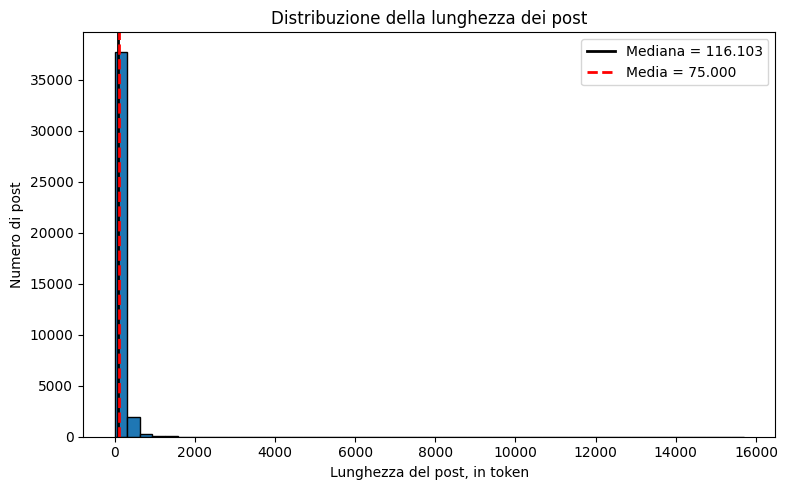

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["post_length"].dropna(),
    bins=50,
    edgecolor="black"
)

mediana_lung = data["post_length"].median()
media_lung = data['post_length'].mean()
plt.axvline(mediana_lung, linestyle="-", linewidth=2, label=f"Mediana = {media_lung:.3f}", color="black")
plt.axvline(media_lung, linestyle="--", linewidth=2, label=f"Media = {mediana_lung:.3f}", color="r")

plt.xlabel("Lunghezza del post, in token")
plt.ylabel("Numero di post")
plt.title("Distribuzione della lunghezza dei post")
plt.tight_layout()
plt.legend()
plt.show()

## TTR

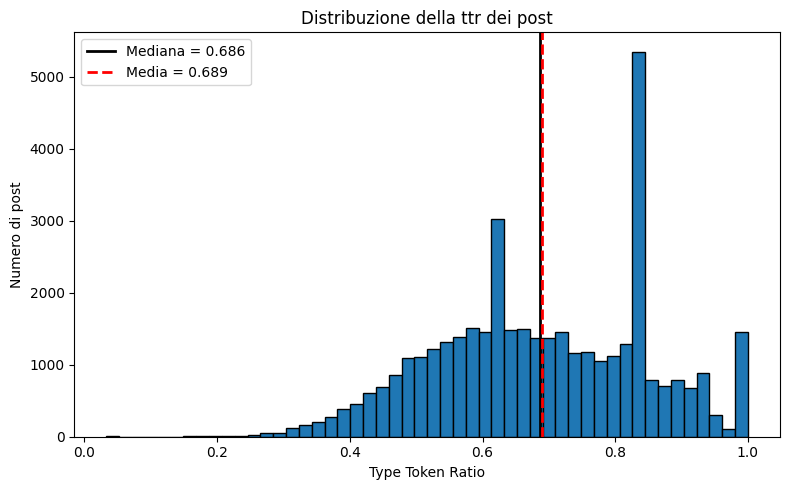

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["ttr"].dropna(),
    bins=50,
    edgecolor="black"
)
mediana_ttr = data["ttr"].median()
media_ttr = data['ttr'].mean()
plt.axvline(mediana_ttr, linestyle="-", linewidth=2, label=f"Mediana = {mediana_ttr:.3f}", color="black")
plt.axvline(media_ttr, linestyle="--", linewidth=2, label=f"Media = {media_ttr:.3f}", color="r")


plt.xlabel("Type Token Ratio")
plt.ylabel("Numero di post")
plt.title("Distribuzione della ttr dei post")
plt.tight_layout()
plt.legend()

plt.show()

## Valutazione della ricchezza lessicale (NGSL)
Utilizzando il vocabolario inglese NGSL, calcolo tutti i termini (non la punteggiatura o gli spazi) non presenti nel NGSL. L'indice per calcolare questa "ricchezza" o complessità è:
$ricchezza = parole_{nuove}/parole_{tot}$

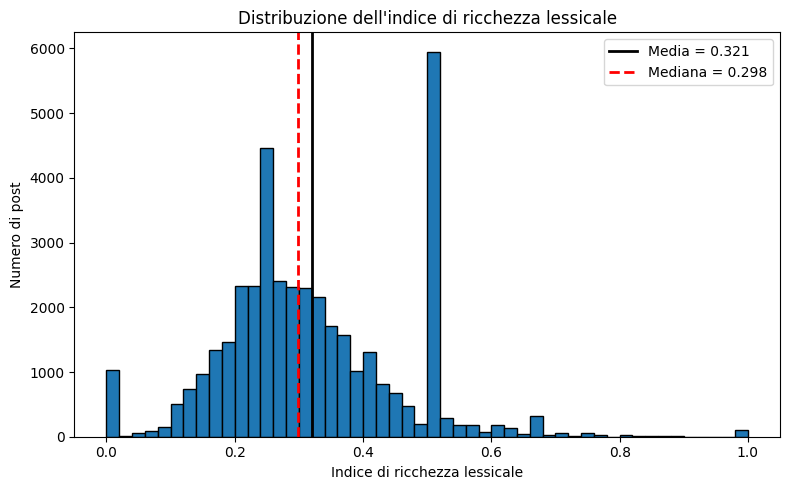

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["ricchezza"].dropna(),
    bins=50,
    edgecolor="black"
)

media = data["ricchezza"].mean()
mediana = data["ricchezza"].median()

plt.axvline(media, linestyle="-", linewidth=2, label=f"Media = {media:.3f}", color="black")
plt.axvline(mediana, linestyle="--", linewidth=2, label=f"Mediana = {mediana:.3f}", color="r")

plt.xlabel("Indice di ricchezza lessicale")
plt.ylabel("Numero di post")
plt.title("Distribuzione dell'indice di ricchezza lessicale")
plt.tight_layout()
plt.legend()

plt.show()

## Profondità media dell'albero sintattico

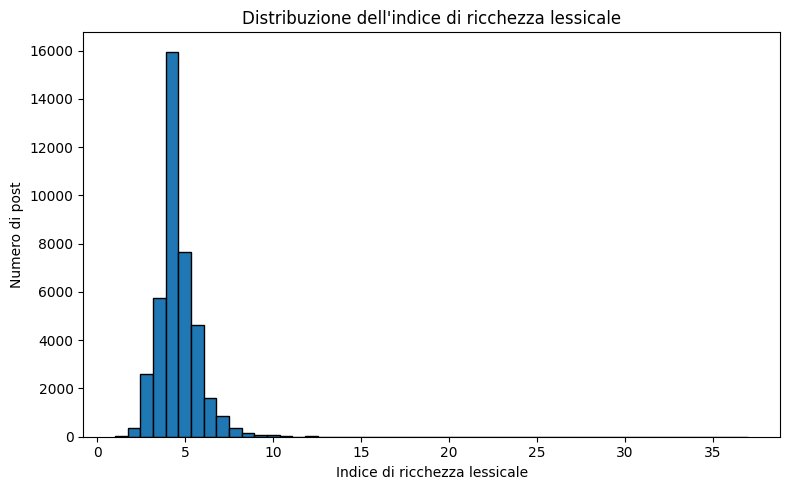

In [49]:
plt.figure(figsize=(8, 5))

plt.hist(
    data["avg_tree_depth"].dropna(),
    bins=50,
    edgecolor="black"
)

plt.xlabel("Indice di ricchezza lessicale")
plt.ylabel("Numero di post")
plt.title("Distribuzione dell'indice di ricchezza lessicale")
plt.tight_layout()

plt.show()

## Prossimi passi:
1. Calcolo di quanto è profondo l'albero sintattico di ogni frase
2. Ricerca di articoli sulla complessità e readability del testo da poi applicare a questo progetto: [LinguA ILC-CNR](http://linguistic-annotation-tool.italianlp.it/) 